# HAGRID Output Analysis

**One config → one call → all results.**

Everything is controlled by a single `RunConfig` dataclass: file paths,
EV model parameters, cost settings, emission options. The notebook only
configures, runs, and displays – zero computation logic.

In [9]:
import sys, pathlib, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# ── Auto-discover hagrid_output_analysis package ─────────────
_nb_dir = pathlib.Path.cwd()
_pkg_name = "hagrid_output_analysis"

def _find_package(start: pathlib.Path, name: str, max_depth: int = 4) -> pathlib.Path | None:
    """
    Locate the *best* top-level package ``name`` in the workspace tree.

    Strategy when multiple ``name/__init__.py`` exist (e.g. tests sub-packages):
      1. Only accept hits where ``name`` is a direct child of its parent
         (i.e. skip  …/tests/name/__init__.py  or  …/name/sub/name/__init__.py).
      2. Prefer ``src/name`` layout (common Python convention).
      3. Among remaining candidates pick the shallowest path (fewest parts).
    """
    candidates: list[pathlib.Path] = []
    for base in [start] + list(start.parents)[:max_depth]:
        for init in base.rglob(f"{name}/__init__.py"):
            pkg_dir = init.parent          # .../hagrid_output_analysis
            src_dir = pkg_dir.parent       # folder that contains the package

            # Reject if the package is *inside* another package with the same name
            # (e.g. hagrid_output_analysis/tests/hagrid_output_analysis)
            if name in [p.name for p in pkg_dir.parents]:
                continue

            candidates.append(src_dir)

    if not candidates:
        return None

    # Prefer  …/src/<pkg>  layout
    src_hits = [c for c in candidates if c.name == "src"]
    if src_hits:
        return min(src_hits, key=lambda p: len(p.parts))

    # Otherwise shortest path = most top-level
    return min(candidates, key=lambda p: len(p.parts))

_src_dir = _find_package(_nb_dir, _pkg_name)
if _src_dir is None:
    raise FileNotFoundError(
        f"Could not locate '{_pkg_name}' package starting from {_nb_dir}. "
        "Make sure the package folder exists somewhere in the workspace."
    )

if str(_src_dir) not in sys.path:
    sys.path.insert(0, str(_src_dir))
    print(f"Added to sys.path: {_src_dir}")

# Force-reload so edits in the package are picked up
for m in [k for k in sys.modules if k.startswith("hagrid_output_analysis")]:
    del sys.modules[m]

from hagrid_output_analysis import (
    ReferenceData, RunConfig,
    process_single_run, discover_runs, run_batch,
    build_kpi_summary, KPI_STRUCTURE,
)

print("hagrid_output_analysis loaded.")

Added to sys.path: c:\Users\bienzeisler\HAGRID\HAGRID\parcel-demand-2-matsim-pipeline\src
hagrid_output_analysis loaded.


## 1 · Configuration

`RunConfig` holds **everything**: simulation files, reference data paths,
EV targets, cost model, emission settings.  Change values here, re-run the
notebook, done.

In [ ]:
# ── Auto-discover hagrid-matsim-output directory ─────────────
def _find_dir(name: str, start: pathlib.Path = _nb_dir, max_depth: int = 4) -> pathlib.Path:
    """Find a directory by name in the workspace tree."""
    for base in [start] + list(start.parents)[:max_depth]:
        for hit in base.rglob(name):
            if hit.is_dir():
                return hit
    raise FileNotFoundError(f"Could not find directory '{name}' from {start}")

MATSIM_OUTPUT = _find_dir("hagrid-matsim-output")
HAGRID_INPUT  = _find_dir("hagrid-input")
RUN_NAME      = "BASECASE_13052025_80_iter50_jsprit10"
SIM_DIR       = MATSIM_OUTPUT / RUN_NAME

# Auto-derive PREFIX from the events file in the run directory
_events = [f.name for f in SIM_DIR.iterdir() if f.name.endswith("output_events.xml.gz")]
if not _events:
    raise FileNotFoundError(f"No output_events.xml.gz found in {SIM_DIR}")
PREFIX = _events[0].replace(".output_events.xml.gz", "")

print(f"SIM_DIR:      {SIM_DIR}")
print(f"HAGRID_INPUT: {HAGRID_INPUT}")
print(f"PREFIX:       {PREFIX}")

cfg = RunConfig(
    # ── Simulation files ──────────────────────────────────────
    event_file         = str(SIM_DIR / f"{PREFIX}.output_events.xml.gz"),
    carrier_file       = str(SIM_DIR / f"{PREFIX}.output_carriers.xml.gz"),
    vehicle_types_file = str(SIM_DIR / f"{PREFIX}.output_carriersVehicleTypes.xml.gz"),

    # ── Reference / spatial data ──────────────────────────────
    network_path        = str(SIM_DIR / f"{PREFIX}.output_network.xml.gz"),
    regionclusters_path = str(HAGRID_INPUT / "geodata" / "regionclusters.pkl"),
    networkplus_path    = str(HAGRID_INPUT / "network" / "networkplus.pkl"),
    plz_areas_csv       = str(HAGRID_INPUT / "geodata" / "plz_areas.csv"),

    # ── Emission settings ─────────────────────────────────────
    emissions_basis        = "CO2",           # "CO2" or "CO2e"
    use_wtw                = False,           # well-to-wheel (only with CO2e)
    idle_pollutants_on     = True,            # compute NOx / HC / CO idle
    without_supply_trucks  = False,           # exclude supply trucks from emissions
    t_long_override        = None,            # override idle t_long [sec], None = use defaults

    # ── Cost model ────────────────────────────────────────────
    vehicle_time_cost_per_sec = 22.87 / 3600, # 22.87 €/h driver cost

    # ── Vehicle classification ────────────────────────────────
    # Auto-matched from vehicleTypes XML via cost signatures!
    # build_vehicle_size_mapping_from_xml() reads the XML, matches each
    # type's (fixedCostsPerDay, costsPerMeter) against BASE_COST_SIGNATURES,
    # and maps numeric size codes (e.g. "80") to emission classes.
    # Only override manually if the auto-matching fails:
    # vehicle_size_mapping = { ... },

    # ── Low-utilisation filter ────────────────────────────────
    low_util_threshold = 0.05,                # drop vehicles below 5% load

    # ── EV fleet model ────────────────────────────────────────
    ev_target = 0.21,                         # 21% fleet-wide EV share

    # Fixed EV shares per provider (applied first, before flexible)
    fixed_ev_shares = {
        "dhl": 0.4807, "dpd": 0.0347,
        "hermes": 0.1117, "fedex": 0.0,
    },

    # Minimum EV shares for flexible providers
    min_ev_shares = {"amazon": 0.10, "gls": 0.02, "ups": 0.02},

    # Providers that receive dynamic EV allocation after fixed quotas
    flexible_providers = frozenset({"amazon", "gls", "ups"}),
)

print(cfg)

SIM_DIR: c:\Users\bienzeisler\HAGRID\HAGRID\parcel-demand-2-matsim-pipeline\hagrid-matsim-output\BASECASE_13052025_80_iter50_jsprit10
PREFIX:  BASECASE_13052025_80
RunConfig(event_file='c:\\Users\\bienzeisler\\HAGRID\\HAGRID\\parcel-demand-2-matsim-pipeline\\hagrid-matsim-output\\BASECASE_13052025_80_iter50_jsprit10\\BASECASE_13052025_80.output_events.xml.gz', carrier_file='c:\\Users\\bienzeisler\\HAGRID\\HAGRID\\parcel-demand-2-matsim-pipeline\\hagrid-matsim-output\\BASECASE_13052025_80_iter50_jsprit10\\BASECASE_13052025_80.output_carriers.xml.gz', vehicle_types_file='c:\\Users\\bienzeisler\\HAGRID\\HAGRID\\parcel-demand-2-matsim-pipeline\\hagrid-matsim-output\\BASECASE_13052025_80_iter50_jsprit10\\BASECASE_13052025_80.output_carriersVehicleTypes.xml.gz', network_path='c:\\Users\\bienzeisler\\HAGRID\\HAGRID\\parcel-demand-2-matsim-pipeline\\hagrid-matsim-output\\BASECASE_13052025_80_iter50_jsprit10\\BASECASE_13052025_80.output_network.xml.gz', regionclusters_path='input/regionclusters

## 2 · Load Reference Data & Run Pipeline

In [11]:
ref = ReferenceData.from_config(cfg)

print(f"Network links:  {len(ref.network):,}")
print(f"Region clusters: {len(ref.regionclusters)}")
print(f"PLZ areas:       {len(ref.gdf_areas)}")

FileNotFoundError: [Errno 2] No such file or directory: 'input/regionclusters.pkl'

In [ ]:
results = process_single_run(cfg, ref)


════════════════════════════════════════════════════════════════════════
  HAGRID Pipeline — Single Run
════════════════════════════════════════════════════════════════════════

▸ [1/9]  Parsing events …
         basecase_13052025.output_events.xml.gz
    ✓  857 vehicles · 473,795 events  (4.69 s)

▸ [2/9]  Merging link counts with network …
    ✓  544,514 links → 77,916 after clip  (22.72 s)

▸ [3/9]  Computing vehicle statistics …
    ✓  857 vehicles enriched  (747.95 ms)

▸ [4/9]  Building timing data …
    ✓  723 CEP tours  (944.86 ms)

▸ [5/9]  Merge & spatial enrichment …

▸ [6/9]  Parsing carriers & demand …
         basecase_13052025.output_carriers.xml.gz


## 3 · Results Overview

In [73]:
result_df = results["emissions_result"]
print(f"Vehicles:  {len(result_df)}")
print(f"Columns:   {result_df.shape[1]}")
result_df.head(3)

Vehicles:  723
Columns:   76


,vehicle_id,Start time,End time,Tour Duration,Service Duration,Travel Duration,Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,stop_density_per_km2,weight_per_km,distance_class,avg_dist_with_init,avg_dist_wo_init,median_dist_with_init,median_dist_wo_init,max_dist_with_init,max_dist_wo_init,failed_delivery_rate
0,freight_ups_30519_veh_cep_size_m_7_3,26652.0,56127.0,29475.0,14619.0,14856.0,1970-01-01 07:24:12,1970-01-01 15:35:27,1970-01-01 08:11:15,1970-01-01 04:03:39,...,8.969016,10.169153,≤ 100,1.197131,0.995460,0.617627,0.615097,14.910739,4.487732,0.024194
1,freight_ups_30519_veh_cep_size_m_7_2,26652.0,55668.0,29016.0,16885.0,12131.0,1970-01-01 07:24:12,1970-01-01 15:27:48,1970-01-01 08:03:36,1970-01-01 04:41:25,...,6.146504,14.607416,≤ 100,1.056094,0.810898,0.539444,0.536510,15.767820,4.415639,0.045455
2,freight_ups_30519_veh_cep_size_m_7_1,26652.0,56520.0,29868.0,18471.0,11397.0,1970-01-01 07:24:12,1970-01-01 15:42:00,1970-01-01 08:17:48,1970-01-01 05:07:51,...,7.342727,17.950554,≤ 100,0.851589,0.593691,0.371337,0.371194,18.904479,4.307526,0.006494


In [74]:
for key in sorted(results.keys()):
    obj = results[key]
    if isinstance(obj, pd.DataFrame):
        desc = f"DataFrame {obj.shape}"
    elif isinstance(obj, dict):
        desc = f"dict ({len(obj)} entries)"
    else:
        desc = type(obj).__name__
    print(f"  {key:<35s} → {desc}")

  emissions_15min_long                → DataFrame (2200704, 5)
  emissions_grid                      → dict (2 entries)
  emissions_result                    → DataFrame (723, 76)
  emissions_wide_cold                 → DataFrame (22924, 97)
  emissions_wide_drive                → DataFrame (22924, 97)
  emissions_wide_idle                 → DataFrame (22924, 97)
  emissions_wide_total                → DataFrame (22924, 97)
  idle_CO_long                        → DataFrame (2200704, 5)
  idle_CO_wide                        → DataFrame (22924, 97)
  idle_HC_long                        → DataFrame (2200704, 5)
  idle_HC_wide                        → DataFrame (22924, 97)
  idle_NOx_long                       → DataFrame (2200704, 5)
  idle_NOx_wide                       → DataFrame (22924, 97)
  merged_15min                        → DataFrame (2200704, 24)
  network_15min_by_area               → DataFrame (864, 4)
  network_15min_pivot                 → DataFrame (96, 9)
  network_totals

## 4 · KPI Dashboard

All KPIs are pre-computed by the pipeline – the cells below only **display** them.

In [75]:
print("--- Cost KPIs ---")
print(f"  Cost/parcel:     {result_df['cost_per_parcel'].median():.2f} € (median)")
print(f"  Cost/km:         {result_df['cost_per_km'].median():.2f} € (median)")
valid_cpk = result_df["cost_per_kg"].dropna()
if len(valid_cpk):
    print(f"  Cost/kg:         {valid_cpk.median():.2f} € (median)")

print("\n--- Time KPIs ---")
print(f"  Tour duration:   {result_df['tour_duration_hrs'].mean():.1f} hrs (mean)")
print(f"  Driving share:   {result_df['driving_share_pct'].mean():.1f} %")
print(f"  Avg speed:       {result_df['avg_speed_kmh'].mean():.1f} km/h")
print(f"  Time/stop:       {result_df['time_per_stop_min'].mean():.1f} min")

print("\n--- Emissions KPIs ---")
print(f"  Emissions/parcel: {result_df['emissions_per_parcel'].median():.1f} g (median)")
print(f"  Emissions/km:     {result_df['emissions_per_km'].median():.1f} g (median)")

print("\n--- Tour Structure ---")
print(f"  Stem share:      {result_df['stem_distance_share'].mean():.1%}")
print(f"  Parcels/km:      {result_df['parcels_per_km'].mean():.2f}")
print(f"  Avg inter-stop:  {result_df['avg_dist_wo_init'].mean():.2f} km")

print("\n--- Distance class distribution ---")
print(result_df["distance_class"].value_counts().sort_index())

--- Cost KPIs ---
  Cost/parcel:     1.38 € (median)
  Cost/km:         3.85 € (median)
  Cost/kg:         0.30 € (median)

--- Time KPIs ---
  Tour duration:   6.6 hrs (mean)
  Driving share:   33.4 %
  Avg speed:       25.6 km/h
  Time/stop:       3.3 min

--- Emissions KPIs ---
  Emissions/parcel: 81.7 g (median)
  Emissions/km:     210.1 g (median)

--- Tour Structure ---
  Stem share:      21.2%
  Parcels/km:      2.93
  Avg inter-stop:  0.64 km

--- Distance class distribution ---
distance_class
≤ 50     357
≤ 100    339
≤ 150     27
≤ 200      0
≤ 250      0
> 250      0
Name: count, dtype: int64


### 4a · Summary Tables

In [76]:
# Summary by aggregated area type (Urban / Suburban / Rural)
summary_agg = build_kpi_summary(result_df, group_col="area_type_agg")
print("=== KPI Summary by Area Type (Urban / Suburban / Rural) ===")
summary_agg.xs("mean", axis=1, level=1).round(2)

=== KPI Summary by Area Type (Urban / Suburban / Rural) ===


,Tour Duration [hrs],Driving Time [hrs],Tour Length [km],Initial Delivery Dist. [km],Stops [#],Mean Inter-Stop Dist. [km],Max Segment Dist. [km],Delivery Area [km²],Driving Share [%],Avg. Speed [km/h],...,Weight/km [kg/km],Vehicle Cost [€],Cost/Parcel [€],Cost/km [€],Cost/kg [€],Emissions [g CO₂],Emissions/Parcel [g],Emissions/km [g],Emissions/kg [g],Vehicles [#]
area_type_agg,,,,,,,,,,,,,,,,,,,,,
Rural,6.45,2.00,55.28,10.81,84.20,0.80,4.84,9.73,32.33,28.99,...,9.02,193.24,1.70,3.54,0.46,11615.66,96.06,209.76,26.04,5
Suburban,6.47,2.28,59.75,11.80,84.57,0.71,3.85,13.09,35.83,26.64,...,12.49,199.23,1.90,3.80,0.41,11744.99,102.54,178.01,21.81,357
Urban,6.64,2.00,48.66,10.43,79.96,0.56,2.86,6.18,31.01,24.61,...,17.54,196.22,1.62,4.54,0.32,9269.05,75.73,170.34,14.38,361


In [77]:
# Summary by detailed area type (8 Raumtypen)
summary_detail = build_kpi_summary(result_df, group_col="main_area_type_name")
summary_detail.xs("mean", axis=1, level=1).round(2)

,Tour Duration [hrs],Driving Time [hrs],Tour Length [km],Initial Delivery Dist. [km],Stops [#],Mean Inter-Stop Dist. [km],Max Segment Dist. [km],Delivery Area [km²],Driving Share [%],Avg. Speed [km/h],...,Weight/km [kg/km],Vehicle Cost [€],Cost/Parcel [€],Cost/km [€],Cost/kg [€],Emissions [g CO₂],Emissions/Parcel [g],Emissions/km [g],Emissions/kg [g],Vehicles [#]
main_area_type_name,,,,,,,,,,,,,,,,,,,,,
Dense Mixed Use,6.49,2.20,54.36,10.71,80.46,0.67,3.48,8.41,34.96,25.23,...,13.80,196.72,1.87,4.01,0.38,10805.96,94.49,184.06,18.16,166
High-Density Residential Use,6.71,1.76,43.60,10.04,81.69,0.45,2.18,4.35,26.79,24.85,...,20.12,195.85,1.42,5.08,0.29,7909.68,58.98,155.25,11.45,154
Industrial Use,6.67,2.47,67.76,10.23,85.84,0.86,4.84,23.34,36.33,27.83,...,11.60,202.41,1.72,3.53,0.37,13925.52,118.33,191.25,24.26,70
Metropolitan Center,7.00,2.12,44.61,10.78,71.49,0.56,2.88,4.03,30.85,21.23,...,22.99,195.60,1.40,4.63,0.23,8152.40,62.66,171.44,10.12,41
Residential Use,6.39,2.23,58.17,12.30,84.61,0.67,3.59,10.46,35.81,26.58,...,12.58,198.55,1.97,3.85,0.42,11345.95,100.12,175.82,21.52,268
Rural without Industrial Influence,6.45,2.00,55.28,10.81,84.20,0.80,4.84,9.73,32.33,28.99,...,9.02,193.24,1.70,3.54,0.46,11615.66,96.06,209.76,26.04,5
Urbanized Periphery,6.75,2.27,52.55,10.64,79.32,0.69,3.80,12.47,34.23,23.07,...,14.52,197.14,1.54,4.07,0.33,9340.11,78.54,160.24,16.88,19


In [78]:
# Cost per parcel by provider × area type
cost_by_prov_area = (
    result_df.groupby(["provider", "area_type_agg"])["cost_per_parcel"]
    .agg(["mean", "median", "std", "count"])
    .round(2)
)
print("=== Cost per Parcel [€] by Provider × Area Type ===")
cost_by_prov_area

=== Cost per Parcel [€] by Provider × Area Type ===


mean  median   std  count
provider area_type_agg                           
amazon   Rural          1.24    1.24   NaN      1
         Suburban       1.39    1.27  0.39     58
         Urban          1.28    1.18  0.30     49
dhl      Rural          1.23    1.20  0.08      3
         Suburban       1.63    1.26  2.23    128
         Urban          1.36    1.20  0.95    129
dpd      Suburban       2.18    2.10  0.86     36
         Urban          1.97    1.45  1.85     31
fedex    Suburban       1.86    1.60  1.23     27
         Urban          1.82    1.44  1.03     39
gls      Suburban       3.20    2.05  3.48     33
         Urban          2.44    2.08  1.41     32
hermes   Rural          3.55    3.55   NaN      1
         Suburban       2.14    1.74  1.21     41
         Urban          1.77    1.50  0.78     34
ups      Suburban       1.93    1.52  1.07     34
         Urban          1.67    1.40  0.72     47

### 4b · Visualisations

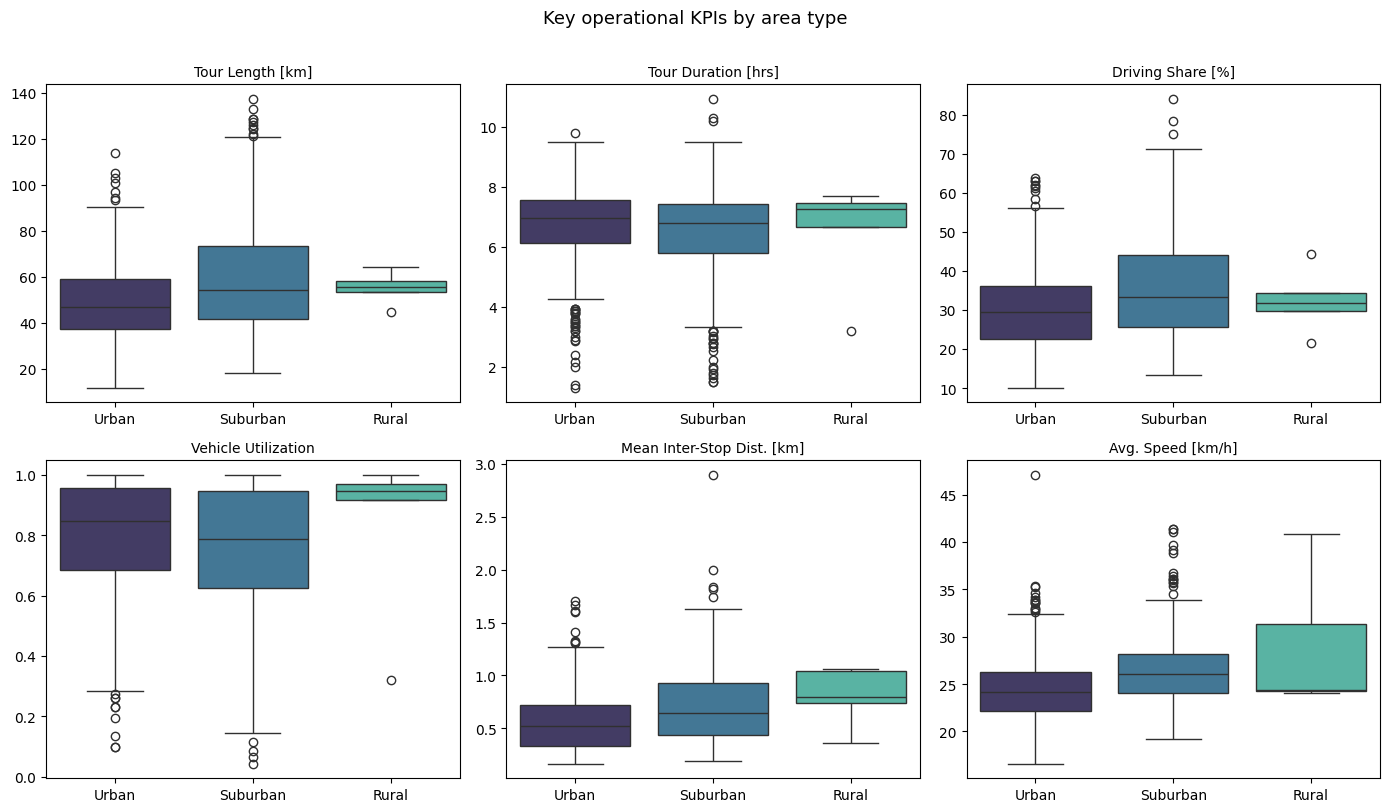

In [79]:
kpi_box = {
    "tour_km":             "Tour Length [km]",
    "tour_duration_hrs":   "Tour Duration [hrs]",
    "driving_share_pct":   "Driving Share [%]",
    "vehicle_load_factor": "Vehicle Utilization",
    "avg_dist_wo_init":    "Mean Inter-Stop Dist. [km]",
    "avg_speed_kmh":       "Avg. Speed [km/h]",
}
area_order = ["Urban", "Suburban", "Rural"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (col, label) in zip(axes.flat, kpi_box.items()):
    sns.boxplot(
        data=result_df, x="area_type_agg", y=col,
        order=area_order, ax=ax, hue="area_type_agg",
        palette="mako", legend=False,
    )
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Key operational KPIs by area type", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Total network emissions: 7,597.2 kg CO₂


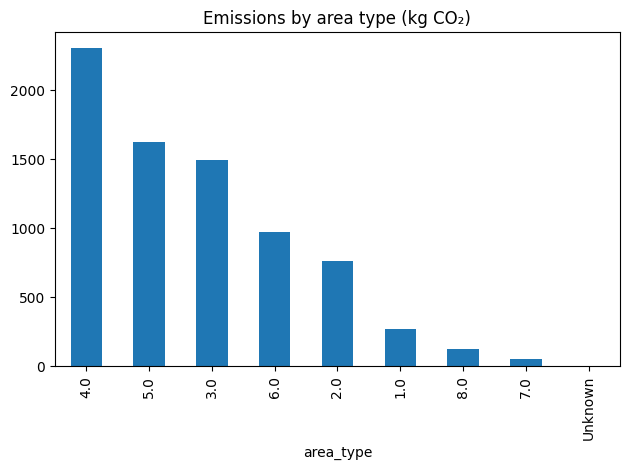

In [80]:
# Emissions by area type
long_df = results["emissions_15min_long"]
total_kg = long_df["emissions_g"].sum() / 1000
print(f"Total network emissions: {total_kg:,.1f} kg CO₂")

by_area = results["network_15min_by_area"]
area_totals = (
    by_area.groupby("area_type")["emissions_kg_sum"]
    .sum()
    .sort_values(ascending=False)
)
area_totals.plot.bar(title="Emissions by area type (kg CO₂)")
plt.tight_layout()
plt.show()

In [81]:
# Vehicle fleet mix by area type
area_order = ["Urban", "Suburban", "Rural"]
fleet_mix = (
    result_df.groupby(["area_type_agg", "veh_size"])
    .size()
    .unstack(fill_value=0)
)
fleet_mix["total"] = fleet_mix.sum(axis=1)
for sz in fleet_mix.columns.drop("total", errors="ignore"):
    fleet_mix[f"pct_{sz}"] = (fleet_mix[sz] / fleet_mix["total"] * 100).round(1)

print("=== Vehicle Fleet Mix by Area Type ===")
for area in area_order:
    if area in fleet_mix.index:
        row = fleet_mix.loc[area]
        parts = ", ".join(
            f"{sz}={int(row.get(sz, 0))} ({row.get(f'pct_{sz}', 0):.0f}%)"
            for sz in ["m", "l"] if sz in fleet_mix.columns
        )
        print(f"  {area}: {int(row['total'])} vehicles – {parts}")

# Carrier category summary
cat_summary = (
    result_df.groupby("carrier_category")
    .agg(
        vehicles=("vehicle_id", "count"),
        deliveries=("deliveries", "sum"),
        cost_per_parcel=("cost_per_parcel", "mean"),
        emissions_per_parcel=("emissions_per_parcel", "mean"),
        avg_speed=("avg_speed_kmh", "mean"),
        utilization=("vehicle_load_factor", "mean"),
    )
    .round(2)
)
print("\n=== Summary by Carrier Category (B2B / B2C / Mixed) ===")
cat_summary

=== Vehicle Fleet Mix by Area Type ===
  Urban: 361 vehicles – m=288 (80%), l=73 (20%)
  Suburban: 357 vehicles – m=318 (89%), l=39 (11%)
  Rural: 5 vehicles – m=5 (100%), l=0 (0%)

=== Summary by Carrier Category (B2B / B2C / Mixed) ===


,vehicles,deliveries,cost_per_parcel,emissions_per_parcel,avg_speed,utilization
carrier_category,,,,,,
B2B,147,18747,1.80,111.68,24.65,0.75
B2C,184,25507,1.61,88.25,28.01,0.81
Mixed,392,53303,1.81,81.05,24.90,0.76


## 5 · Batch Processing

`discover_runs()` finds all simulation runs under a directory.
`run_batch()` processes them all, using `cfg` as a template
(file paths are overridden per discovered run).

In [ ]:
BATCH_DIR  = r"input\simRes\batch"
OUTPUT_DIR = r"input\simRes\batch\processed"

runs = discover_runs(BATCH_DIR)
print(f"Found {len(runs)} runs:")
for r in runs:
    print(f"  {r['scenario']}/{r['run_name']}")

# Uncomment to actually run:
# run_batch(batch_dir=BATCH_DIR, output_base=OUTPUT_DIR, ref=ref, cfg=cfg)